# 13) Forecast Collinearity & PCA Audit

Ziel dieses Notebooks:
- Forecast-Familien automatisch identifizieren.
- Multikollinearität je Familie mit Korrelation und VIF prüfen.
- PCA je Familie (train-fit only) auf 95% erklärte Varianz bewerten.
- Entscheidungstabelle erzeugen: `keep raw` vs `replace by PCs`.
- Optionaler A/B-Vergleich (Raw vs PCA) für MAE und vereinfachtes PnL.

In [1]:
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd

def _resolve_repo_root() -> Path:
    root = Path.cwd().resolve()
    if (root / 'src').exists():
        return root
    for p in root.parents:
        if (p / 'src').exists():
            return p
    raise RuntimeError("Could not resolve REPO_ROOT (directory containing 'src').")

REPO_ROOT = _resolve_repo_root()
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

sns.set_theme(style='whitegrid')

FEATURE_PATH = REPO_ROOT / 'data/features/all_data_features.parquet'
PICASSO_START_UTC = pd.Timestamp('2022-06-22 22:00:00+00:00')
TRAIN_END = pd.Timestamp('2024-01-01 00:00:00+00:00')
VAL_END = pd.Timestamp('2024-07-01 00:00:00+00:00')
TARGET_COL = 'target_afrr_activation_price_vwap_pos_h1'

FAMILY_PATTERNS = {
    'load_forecast': r'^load_forecast',
    'residual_load_forecast': r'^residual_load_forecast',
    'wind_onshore_forecast': r'^wind_onshore_forecast',
    'wind_offshore_forecast': r'^wind_offshore_forecast',
    'solar_forecast': r'^solar_forecast',
}

assert FEATURE_PATH.exists(), f'Missing feature file: {FEATURE_PATH}'

df = pd.read_parquet(FEATURE_PATH)
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True, errors='coerce')
df = df.dropna(subset=['timestamp_utc']).sort_values('timestamp_utc').reset_index(drop=True)
df = df[df['timestamp_utc'] >= PICASSO_START_UTC].reset_index(drop=True)

print('rows:', len(df), 'cols:', len(df.columns))
print('start:', df['timestamp_utc'].min(), 'end:', df['timestamp_utc'].max())

rows: 32333 cols: 174
start: 2022-06-22 22:00:00+00:00 end: 2026-03-01 02:00:00+00:00


In [2]:
def family_map(columns):
    out = {}
    for fam, pat in FAMILY_PATTERNS.items():
        rx = re.compile(pat)
        cols = [c for c in columns if rx.match(c)]
        cols = [c for c in cols if ('forecast' in c or '_lag_' in c)]
        if cols:
            out[fam] = sorted(cols)
    return out

families = family_map(df.columns)
pd.DataFrame([
    {'family': fam, 'n_cols': len(cols), 'example_cols': ', '.join(cols[:5])}
    for fam, cols in families.items()
]).sort_values('family')

,family,n_cols,example_cols
0,residual_load_forecast,4,"residual_load_forecast, residual_load_forecast..."
3,solar_forecast,5,"solar_forecast_id_entsoe, solar_forecast_id_en..."
2,wind_offshore_forecast,4,"wind_offshore_forecast_id_entsoe, wind_offshor..."
1,wind_onshore_forecast,5,"wind_onshore_forecast_id_entsoe, wind_onshore_..."


In [3]:
def max_abs_corr(x: pd.DataFrame) -> float:
    if x.shape[1] < 2:
        return 0.0
    c = x.corr(numeric_only=True).abs()
    arr = c.to_numpy(copy=True)  # writable copy
    np.fill_diagonal(arr, np.nan)
    v = np.nanmax(arr)
    return float(v) if np.isfinite(v) else 0.0


def max_vif(x: pd.DataFrame) -> float:
    if x.shape[1] < 2:
        return 1.0
    arr = np.asarray(x, dtype=float)
    out = 1.0
    for i in range(arr.shape[1]):
        y = arr[:, i]
        o = np.delete(arr, i, axis=1)
        if o.shape[1] == 0:
            continue
        X = np.column_stack([np.ones(len(y)), o])
        coef, *_ = np.linalg.lstsq(X, y, rcond=None)
        y_hat = X @ coef
        ss_res = float(np.sum((y - y_hat) ** 2))
        ss_tot = float(np.sum((y - np.mean(y)) ** 2))
        if ss_tot <= 0:
            continue
        r2 = 1.0 - (ss_res / ss_tot)
        r2 = min(max(r2, 0.0), 0.999999)
        vif = 1.0 / (1.0 - r2)
        if np.isfinite(vif):
            out = max(out, float(vif))
    return out

In [4]:
summary_rows = []
for fam, cols in families.items():
    block = df[cols].copy()
    block = block.fillna(block.median(numeric_only=True)).fillna(0.0)
    train = block[df['timestamp_utc'] < TRAIN_END]

    if train.empty:
        continue

    corr = max_abs_corr(train)
    vif = max_vif(train)

    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train)
    pca_full = PCA().fit(train_scaled)
    cum = np.cumsum(pca_full.explained_variance_ratio_)
    ncomp_95 = int(np.searchsorted(cum, 0.95) + 1)

    action = 'replace by PCs' if (corr > 0.9 or vif > 10.0) and len(cols) >= 2 else 'keep raw'

    summary_rows.append({
        'family': fam,
        'n_cols': len(cols),
        'max_abs_corr_train': corr,
        'max_vif_train': vif,
        'n_comp_95pct': ncomp_95,
        'explained_var_95pct': float(cum[ncomp_95 - 1]),
        'recommendation': action,
    })

summary = pd.DataFrame(summary_rows).sort_values('family')
summary

,family,n_cols,max_abs_corr_train,max_vif_train,n_comp_95pct,explained_var_95pct,recommendation
0,residual_load_forecast,4,0.648315,2.382817,4,1.000000,keep raw
3,solar_forecast,5,0.951304,16.090250,2,0.957399,replace by PCs
2,wind_offshore_forecast,4,0.407909,1.367929,4,1.000000,keep raw
1,wind_onshore_forecast,5,0.590372,2.016278,5,1.000000,keep raw


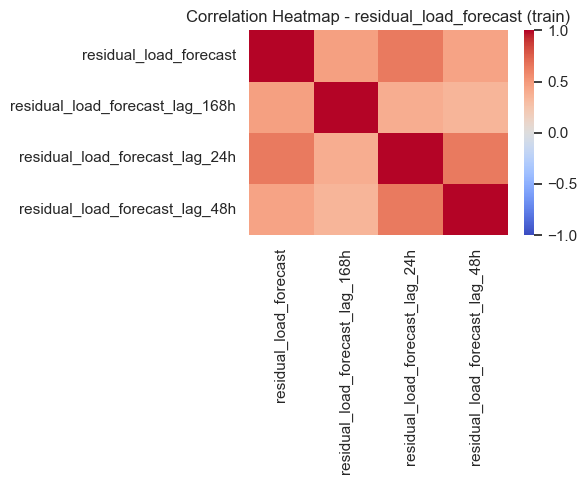

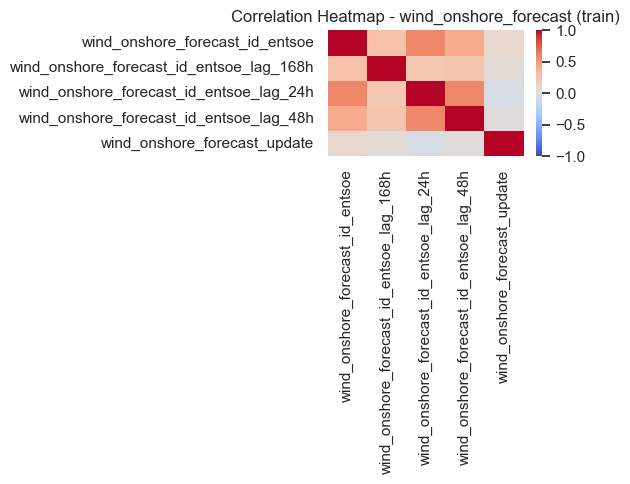

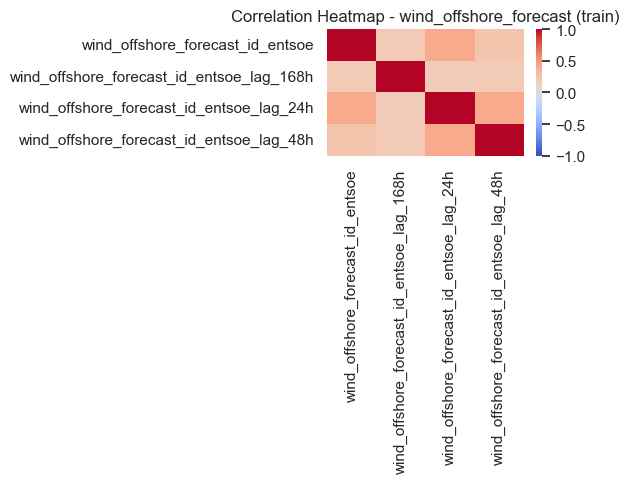

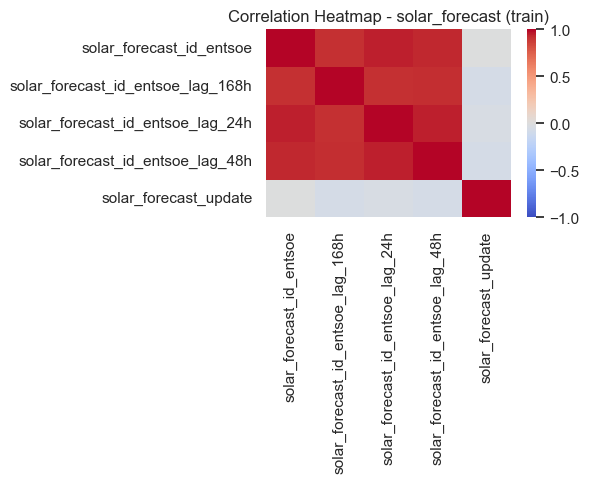

In [5]:
# Correlation heatmaps je Familie
for fam, cols in families.items():
    if len(cols) < 2:
        continue
    train = df.loc[df['timestamp_utc'] < TRAIN_END, cols].copy()
    train = train.fillna(train.median(numeric_only=True)).fillna(0.0)
    corr = train.corr()

    plt.figure(figsize=(min(14, max(6, len(cols) * 0.45)), 5))
    sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title(f'Correlation Heatmap - {fam} (train)')
    plt.tight_layout()
    plt.show()

## Entscheidungskriterien

Eine Familie wird als `replace by PCs` markiert, wenn mindestens eines gilt:
- hohe Korrelation: `max(|corr|) > 0.9`
- hohe Multikollinearität: `max VIF > 10`

Zusätzlich wird `n_comp_95pct` ausgewiesen, um die Dimension für PCA festzulegen.

**Methodischer Hinweis:**
- Hohe Korrelation **innerhalb einer Forecast-Familie (inkl. Lags)** ist erwartet und ein zentrales Motiv für PCA.
- Die **Leakage-Prüfung** erfolgt separat auf **ungelagten, nicht-prognostischen** Features.


## Leakage-Sanity-Check (separat von PCA-Familienanalyse)

Diese Sektion prüft explizit nur **ungelaggte** Features, die **keine Targets**,
**keine Forecast-Ausnahmen** und **keine Kalender-/Metadaten-Spalten** sind.

Ziel: Sichtprüfung, ob bei den verbleibenden Rohsignalen auffällige Korrelationen
vorliegen, die als Leakage-Hinweis untersucht werden sollten.


Leakage-Sanity candidate columns: 27


,column
0,afrr_capacity_price_neg
1,afrr_capacity_price_pos
2,afrr_capacity_offered_mw_neg
3,afrr_capacity_offered_mw_pos
4,wind_onshore_capacity
5,wind_offshore_capacity
6,solar_capacity
7,gas_capacity
8,hard_coal_capacity
9,lignite_capacity


High-corr pairs (|corr|>=0.9): 17


,col_a,col_b,abs_corr
0,wind_onshore_capacity,hard_coal_capacity,0.999965
1,solar_capacity,gas_capacity,0.999810
2,wind_onshore_capacity,solar_capacity,0.999611
3,solar_capacity,hard_coal_capacity,0.999340
4,wind_onshore_capacity,gas_capacity,0.998877
5,gas_capacity,hard_coal_capacity,0.998443
6,da_price_mean_24h,da_price_ewma24,0.995131
7,gas_price,coal_price,0.941478
8,da_price_pit,da_price_ewma24,0.929829
9,da_price_mean_168h,da_price_ewma24,0.924698


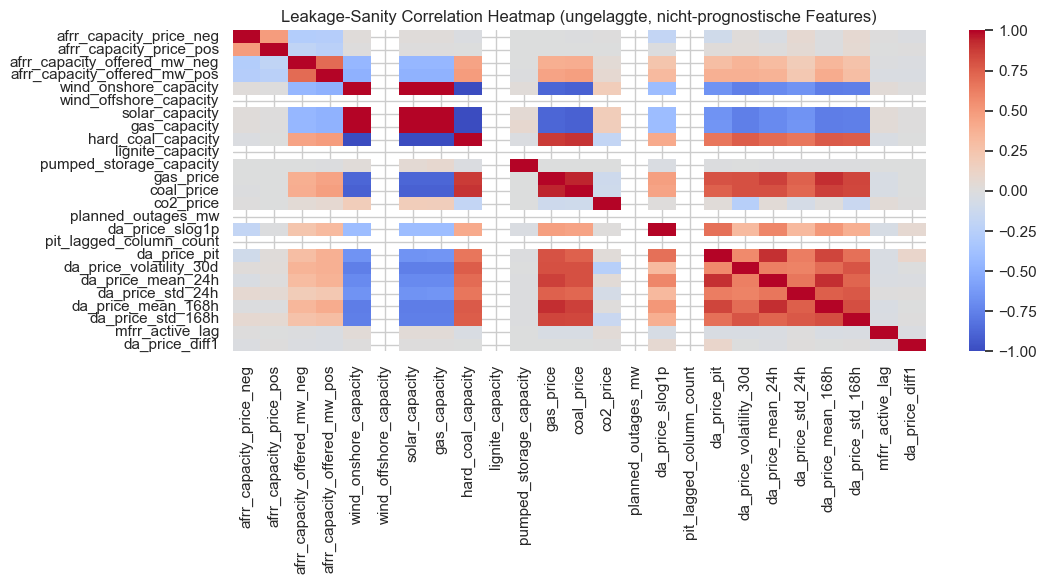

In [6]:
# Leakage-Sanity-Check: ungelaggte, nicht-prognostische Features

meta_cols = {'timestamp_utc'}
calendar_meta_cols = {
    'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
    'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos',
    'is_weekend', 'is_bridge_day', 'is_christmas_break',
    'is_afternoon', 'is_morning', 'is_evening', 'is_night',
    'is_payday_period', 'holiday_severity',
    'is_picasso_active', 'is_picasso_regime', 'market_regime_picasso'
}


def is_forecast_exception(col: str) -> bool:
    c = col.lower()
    return ('forecast' in c) or c.endswith('_update')


def is_excluded_for_leakage_check(col: str) -> bool:
    if col in meta_cols or col in calendar_meta_cols:
        return True
    if col.startswith('target_'):
        return True
    if '_lag_' in col:
        return True
    if is_forecast_exception(col):
        return True
    return False

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
leakage_cols = [c for c in num_cols if not is_excluded_for_leakage_check(c)]

print('Leakage-Sanity candidate columns:', len(leakage_cols))
display(pd.DataFrame({'column': leakage_cols}).head(100))

if len(leakage_cols) >= 2:
    train_leak = df.loc[df['timestamp_utc'] < TRAIN_END, leakage_cols].copy()
    train_leak = train_leak.fillna(train_leak.median(numeric_only=True)).fillna(0.0)
    corr_abs = train_leak.corr().abs()

    # Paarliste mit hoher Korrelation
    pairs = []
    cols = corr_abs.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            v = corr_abs.iloc[i, j]
            if np.isfinite(v) and v >= 0.9:
                pairs.append((cols[i], cols[j], float(v)))

    high_corr_pairs = (
        pd.DataFrame(pairs, columns=['col_a', 'col_b', 'abs_corr'])
        .sort_values('abs_corr', ascending=False)
        .reset_index(drop=True)
        if pairs else pd.DataFrame(columns=['col_a', 'col_b', 'abs_corr'])
    )

    print('High-corr pairs (|corr|>=0.9):', len(high_corr_pairs))
    display(high_corr_pairs.head(50))

    # Heatmap kompakt halten
    show_cols = leakage_cols if len(leakage_cols) <= 25 else leakage_cols[:25]
    plt.figure(figsize=(max(7, len(show_cols) * 0.45), 6))
    sns.heatmap(train_leak[show_cols].corr(), cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title('Leakage-Sanity Correlation Heatmap (ungelaggte, nicht-prognostische Features)')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough columns for leakage sanity correlation check.')


In [7]:
# Optionaler A/B-Vergleich (Raw vs PCA) auf MAE + vereinfachtes PnL

def build_xy(frame, target_col):
    use = frame.copy()
    use = use.dropna(subset=[target_col])
    y = use[target_col].astype(float)
    drop_cols = ['timestamp_utc', target_col] + [c for c in use.columns if c.startswith('target_') and c != target_col]
    X = use.drop(columns=[c for c in drop_cols if c in use.columns], errors='ignore')
    X = X.select_dtypes(include=[np.number])
    X = X.fillna(X.median(numeric_only=True))
    return X, y

train = df[df['timestamp_utc'] < TRAIN_END].copy()
val = df[(df['timestamp_utc'] >= TRAIN_END) & (df['timestamp_utc'] < VAL_END)].copy()

if TARGET_COL in df.columns and len(train) > 200 and len(val) > 100:
    Xtr_raw, ytr = build_xy(train, TARGET_COL)
    Xva_raw, yva = build_xy(val, TARGET_COL)

    common = [c for c in Xtr_raw.columns if c in Xva_raw.columns]
    Xtr_raw = Xtr_raw[common]
    Xva_raw = Xva_raw[common]

    mdl_raw = Ridge(alpha=1.0)
    mdl_raw.fit(Xtr_raw, ytr)
    pred_raw = mdl_raw.predict(Xva_raw)
    mae_raw = mean_absolute_error(yva, pred_raw)

    # PCA-ersetze nur empfohlene Familien
    Xtr_pca = Xtr_raw.copy()
    Xva_pca = Xva_raw.copy()

    for _, row in summary.iterrows():
        if row['recommendation'] != 'replace by PCs':
            continue
        fam = row['family']
        cols = [c for c in Xtr_pca.columns if re.match(FAMILY_PATTERNS[fam], c)]
        if len(cols) < 2:
            continue
        scaler = StandardScaler()
        tr_block = scaler.fit_transform(Xtr_pca[cols])
        va_block = scaler.transform(Xva_pca[cols])
        ncomp = int(row['n_comp_95pct'])
        pca = PCA(n_components=ncomp)
        tr_pc = pca.fit_transform(tr_block)
        va_pc = pca.transform(va_block)
        for i in range(ncomp):
            Xtr_pca[f'{fam}_pc{i+1}'] = tr_pc[:, i]
            Xva_pca[f'{fam}_pc{i+1}'] = va_pc[:, i]
        Xtr_pca = Xtr_pca.drop(columns=cols, errors='ignore')
        Xva_pca = Xva_pca.drop(columns=cols, errors='ignore')

    common2 = [c for c in Xtr_pca.columns if c in Xva_pca.columns]
    Xtr_pca = Xtr_pca[common2]
    Xva_pca = Xva_pca[common2]

    mdl_pca = Ridge(alpha=1.0)
    mdl_pca.fit(Xtr_pca, ytr)
    pred_pca = mdl_pca.predict(Xva_pca)
    mae_pca = mean_absolute_error(yva, pred_pca)

    # Vereinfachtes PnL (Top/Bottom 20% Signale)
    q_hi_raw = np.quantile(pred_raw, 0.8)
    q_lo_raw = np.quantile(pred_raw, 0.2)
    signal_raw = np.where(pred_raw >= q_hi_raw, 1, np.where(pred_raw <= q_lo_raw, -1, 0))
    pnl_raw = float(np.sum(signal_raw * yva.to_numpy()))

    q_hi_pca = np.quantile(pred_pca, 0.8)
    q_lo_pca = np.quantile(pred_pca, 0.2)
    signal_pca = np.where(pred_pca >= q_hi_pca, 1, np.where(pred_pca <= q_lo_pca, -1, 0))
    pnl_pca = float(np.sum(signal_pca * yva.to_numpy()))

    pd.DataFrame([
        {'setup': 'raw', 'mae': mae_raw, 'pnl_proxy': pnl_raw},
        {'setup': 'pca_replace', 'mae': mae_pca, 'pnl_proxy': pnl_pca},
    ])
else:
    print('Skip optional A/B: target missing or not enough rows.')

In [8]:
# Persistiere Entscheidungsreport fuer spaetere Pipeline-Entscheidung
out = REPO_ROOT / 'data/reports/forecast_pca_family_recommendation.csv'
out.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(out, index=False)
out


PosixPath('/Users/leori/Code/energyTrading/data/reports/forecast_pca_family_recommendation.csv')